# Predicting College and NFL Games for Pick 4 (my silly sports picking league)
## Background
With (American) football season kicking off soon (tonight!) I thought it would be a good opportunity to add some rigor to my process for picking college and pro football teams against my friends in our silly sports picking leagues. My favorite friends league is called Pick 4 and involves picking exactly four games against the spread each week. Any college game involving an FBS (the top division) team or any NFL game is eligble. 

## My current approach

Although most games are played on Saturday and Sunday, in this league lines lock on Tuesdays. This means that the live (real) line can move quite a bit (due to news or large quantities of money being placed on one of the teams) while the Pick 4 line stays fixed in place at the Tuesday line. When the live line and our fixed Pick 4 line move out of sync it can provide a delightful opportunity for arbitrage. 

Another factor I consider is the percentage of bets that are placed on a team and how the line moves relative to that team. If a team receives a small percentage of bets but the line moves to make it less favorable to bet on that team, this is called [reverse line movement](https://www.actionnetwork.com/education/reverse-line-movement) and it is an indicator that sharp money is betting on that team. 

At a high level, my current approach to picking games in our Pick 4 league has been:
- Scrape Office Football Pool for Pick 4 lines as soon as our lines lock on Tuesdays
- Scrape [Action Network](https://www.actionnetwork.com/nfl/public-betting) for live NFL and College Football game lines and percentage of bets placed on a team
- Join the Office Football Pool data with the most recent Action Network data
- Calculate the opportunity of each game based on a complex heuristic I've developed that considers aribtrage opportunity and reverse line movement and sort games by best opportunity 
- Make picks

This system has been remarkably successful and I have at least tied for first in our Pick 4 pool three of the last four years.

## Goals for this post
The purpose of this project is to add more rigor to my Pick 4 game picking process. Although my existing process has borne fruit, it leans too heavily on intuition and I'd like to use machine learning to see if I can beat my existing vibes-based approach. 

Before we proceed, I'd like to call out that I had previously factored [circadian rhythms](https://deadspin.com/the-circadian-advantage-how-sleep-patterns-benefit-cer-5934440/) into my picks until [I investigated this phenomenon two years ago](https://ianvaronin.com/2024/10/15/nfl_circadian_rhythm.htlr) and determined that was no longer a viable signal. 

## A note on LLMs
It's very clear that LLMs make excellent computer and data scientists. However, I chose not to ask an AI to do this for me. This is my own work. I believe that it's important to actually know how to write code, analyze data, and create and evaluate predictions instead of relying on AI to do all of that. LLMs are powerful force multipliers but they can and do make mistakes or miss things. A good data science practioner should be able to check the work of an LLM and therefore needs to understand how to do this sort of work. An LLM could probably have done this whole thing in 1/25 the time and done at least as good of a job but that's not the point of the post. In addition to trying to build something useful for me this was meant as exercise to help me learn and improve my skills. I enjoyed working on it. 

With that preamble out of the way, let's dive into the approach I plan to use here.

## The plan
1. Get game result data for the past few season
2. Join my existing Office Football Pool and Action Network data to the game result data
3. Build and tune a machine learning model to predict whether each favored team would cover the Pick 4 spread given the data available in that moment
4. Compare the model's predictive abilities against my existing process for choosing games

Since we must pick the outcomes of exactly four games each week, it is important to rank the confidence of our weekly picks so we can sort them. While decision trees lack such functionality, logistic regression classifiers can return probability estimates making that approach well suited to this type of problem.

To get started I will run through the process that I used to get game result data and join it to my existing Office Football Pool and Action Network data.

As with my last post we will use python and the pandas library, which is well suited for data wrangling. First we will import the pandas and sqlite3 libraries which we will immediately need.

## Import Office Football Pool Data

In [1]:
import pandas as pd
import sqlite3

Going back to October 2023, every time I scraped Action Network and joined it to Office Football Pool data I saved the data to an sqlite database in a table called `game_lines`. Let's read all the data from that table into a pandas dataframe.

In [2]:
with sqlite3.connect('pick_four') as conn:
    query = "SELECT * FROM game_lines"
    df = pd.read_sql_query(query, conn)

Let's take a look at the shape of the data and first few rows.

### Investigate the Data

In [3]:
df.shape

(21461, 37)

In [4]:
pd.options.display.max_columns = 100
df.sort_values(by='current_datetime').head()

,rot_num_away,rot_num_home,ofp_game_id,team_concat,organization,game_time,away_team,away_open_line,away_current_best_line,ofp_away_line,away_odds,away_bet_percentage,home_team,home_open_line,home_current_best_line,ofp_home_line,home_odds,home_bet_percentage,max_free_points,max_free_points_team,line_movement_team,reverse_line_movement,circadian_rhythm,away_team_time_zone_offset,home_team_time_zone_offset,free_points_strength,line_movement_strength,line_movement_%_bets_value_away_team,line_movement_%_bets_value_home_team,free_points_value_away_team,free_points_value_home_team,circadian_rhythm_points_away,circadian_rhythm_points_home,recommendation_team,current_datetime,max_recommendation_points,net_recommendation_points
0,341,342,42211,tulsaflorida atl.,College,15:00,tulsa,3.5,2.5,4.5,+104,17.0,florida atl.,-3.5,-3.0,-4.5,-110,83.0,2.0,tulsa,tulsa,tulsa,None,-1.0,0.0,very strong,very strong,30.0,0.50,64.0,0.0,0,0,tulsa,2023-10-07 08:59:16.483178,94.0,None
35,395,396,42244,connecticutrice,College,14:00,connecticut,10.0,10.5,9.5,-110,22.0,rice,-10.0,-9.5,-9.5,-110,78.0,0.0,rice,None,None,None,0.0,-1.0,,None,4.0,0.50,0.0,0.0,0,0,connecticut,2023-10-07 08:59:16.483178,4.0,None
36,403,404,42212,texas stateul lafayette,College,12:30,texas state,1.0,2.5,1.5,-118,28.0,ul lafayette,-1.0,-1.0,-1.5,-110,72.0,-0.5,ul lafayette,None,None,None,-1.0,0.0,very weak,None,4.0,0.75,0.0,0.0,0,0,texas state,2023-10-07 08:59:16.483178,4.0,None
37,467,468,43184,philadelphiala rams,NFL,13:05,philadelphia,-6.5,-4.0,-4.5,-109,48.0,la rams,6.5,4.0,4.5,-108,52.0,0.5,la rams,la rams,None,None,0.0,-3.0,very weak,medium,2.0,4.00,0.0,1.0,0,0,la rams,2023-10-07 08:59:16.483178,5.0,None
38,303,304,42190,fiunew mexico st.,College,Final,fiu,5.5,6.5,6.5,-105,43.0,new mexico st.,-5.5,-7.0,-6.5,+100,57.0,0.5,new mexico st.,new mexico st.,None,None,0.0,-2.0,very weak,medium,2.0,4.00,0.0,1.0,0,0,new mexico st.,2023-10-07 08:59:16.483178,5.0,None


Let's take a look at the number of null rows in each column.

In [5]:
df.isna().sum()

rot_num_away                              873
rot_num_home                              873
ofp_game_id                             10791
team_concat                                 0
organization                                0
game_time                                   0
away_team                                   0
away_open_line                              0
away_current_best_line                      0
ofp_away_line                            6320
away_odds                                 684
away_bet_percentage                      2354
home_team                                   0
home_open_line                              0
home_current_best_line                      0
ofp_home_line                            6320
home_odds                                 684
home_bet_percentage                      2400
max_free_points                             0
max_free_points_team                    10089
line_movement_team                       3645
reverse_line_movement             

Right away we notice a few interesting things:
- There are a lot of columns, many more than we need for this project
- Some important columns like `ofp_away_line` and `ofp_home_line` have null values. If values for these columns are null, that means the game did not actually exist in Office Football Pool and the row can safely be dropped
- Although there are columns for `gametime` and `current_datetime`, neither of these has the date the game was played

When I pulled this data, I spent a lot of time trying to extract the game date from Action Network and Office Football Pool without success. That technical debt has come back to bite us now. We want to know the date the game was played in order to join this data to game outcome data. Fortunately, we do know some clues for each game that can help us derive the game date: the home team, the away team, and the datetime the data was pulled. The datetime the data was pulled would be immediately before the actual date when the game was played. We can use these clues to help us derive the actual date the game was played.

First let's drop unusable rows where `ofp_away_line` is null and then recheck the count of null values per column.

### Drop Nulls

In [6]:
df = df.dropna(subset='ofp_away_line', ignore_index=True)

In [7]:
df[['ofp_away_line', 'ofp_home_line']].isna().sum()

ofp_away_line    0
ofp_home_line    0
dtype: int64

Good, now every row has as non-null value for `ofp_away_line` and `ofp_home_line`.

### Remove Duplicates

Let's take a look at duplicate values. Because I saved the data multiple times per week (every time I scraped Action Network and joined it to Office Football Pool there will be an entry), I expect there will be many duplicates.

In [8]:
df['ofp_game_id'].value_counts().head()

ofp_game_id
43427    17
43454    17
43429    17
43419    17
44202    15
Name: count, dtype: int64

I believe the field `ofp_game_id` is unique for each game but we should verify this by creating a dataframe where each `away_team`, `home_team`, and `ofp_game_id` combination is assigned to a row. Then we can check and see how many unique `ofp_game_id` values there are.  

In [9]:
ofp_game_id_dupes = df.groupby(['away_team', 'home_team', 'ofp_game_id']).size().reset_index().rename(columns={0:'count'})
ofp_game_id_dupes.head(10)

,away_team,home_team,ofp_game_id,count
0,air force,army,44823,5
1,air force,baylor,44106,6
2,air force,boise st.,43062,9
3,air force,colorado st.,42582,7
4,air force,hawaii,42794,7
5,air force,navy,42417,6
6,air force,nevada,45156,5
7,air force,new mexico,44561,5
8,air force,san diego st.,45284,4
9,air force,wyoming,44283,5


In [10]:
ofp_game_id_dupes['ofp_game_id'].value_counts(ascending=False)

ofp_game_id
44823    1
44264    1
44534    1
42732    1
44710    1
        ..
43009    1
43798    1
43326    1
44370    1
45318    1
Name: count, Length: 1747, dtype: int64

We can confirm that each `ofp_game_id` is unique.

To double verify this, if we look at a specific `ofp_game_id` with multiple entries the `away_team` and `home_team` should be the same. 

In [11]:
df.loc[df['ofp_game_id'] == df['ofp_game_id'].value_counts(
    ).head(1).index[0]].sort_values(by='current_datetime', ascending=False)

,rot_num_away,rot_num_home,ofp_game_id,team_concat,organization,game_time,away_team,away_open_line,away_current_best_line,ofp_away_line,away_odds,away_bet_percentage,home_team,home_open_line,home_current_best_line,ofp_home_line,home_odds,home_bet_percentage,max_free_points,max_free_points_team,line_movement_team,reverse_line_movement,circadian_rhythm,away_team_time_zone_offset,home_team_time_zone_offset,free_points_strength,line_movement_strength,line_movement_%_bets_value_away_team,line_movement_%_bets_value_home_team,free_points_value_away_team,free_points_value_home_team,circadian_rhythm_points_away,circadian_rhythm_points_home,recommendation_team,current_datetime,max_recommendation_points,net_recommendation_points
4746,263,264,43427,missouriohio st.,College,Final,missouri,4.5,4.5,1.5,-114,61.0,ohio st.,-4.5,13.5,-1.5,+200,39.0,-3.0,missouri,None,None,None,-1.0,0.0,very weak,None,0.0,0.375,0.0,0.0,0,0,ohio st.,2023-12-31 09:52:34.536005,0.375,None
4742,263,264,43427,missouriohio st.,College,Final,missouri,4.5,4.5,1.5,-114,61.0,ohio st.,-4.5,13.5,-1.5,+200,39.0,-3.0,missouri,None,None,None,-1.0,0.0,very weak,None,0.0,0.375,0.0,0.0,0,0,ohio st.,2023-12-31 08:43:58.836016,0.375,None
4738,263,264,43427,missouriohio st.,College,Final,missouri,4.5,4.5,1.5,-114,61.0,ohio st.,-4.5,13.5,-1.5,+200,39.0,-3.0,missouri,None,None,None,-1.0,0.0,very weak,None,0.0,0.375,0.0,0.0,0,0,ohio st.,2023-12-30 16:47:14.797736,0.375,None
4730,263,264,43427,missouriohio st.,College,Final,missouri,4.5,4.5,1.5,-114,61.0,ohio st.,-4.5,13.5,-1.5,+200,39.0,-3.0,missouri,None,None,None,-1.0,0.0,very weak,None,0.0,0.375,0.0,0.0,0,0,ohio st.,2023-12-30 09:01:44.549546,0.375,None
4658,263,264,43427,missouriohio st.,College,17:00,missouri,6.5,4.5,1.5,-114,65.0,ohio st.,-6.5,-4.0,-1.5,-108,35.0,2.5,ohio st.,missouri,None,None,-1.0,0.0,elite,strong,0.0,0.375,0.0,160.0,0,0,ohio st.,2023-12-29 16:20:24.119919,160.375,None
4616,263,264,43427,missouriohio st.,College,17:00,missouri,6.5,5.5,1.5,-110,63.0,ohio st.,-6.5,-5.0,-1.5,-105,37.0,3.5,ohio st.,missouri,None,None,-1.0,0.0,elite,strong,0.0,0.375,0.0,224.0,0,0,ohio st.,2023-12-29 14:41:20.272406,224.375,None
4577,263,264,43427,missouriohio st.,College,17:00,missouri,6.5,5.5,1.5,-110,62.0,ohio st.,-6.5,-4.5,-1.5,-113,38.0,3.0,ohio st.,missouri,None,None,-1.0,0.0,elite,strong,0.0,0.375,0.0,192.0,0,0,ohio st.,2023-12-29 10:56:28.935776,192.375,None
4537,263,264,43427,missouriohio st.,College,17:00,missouri,6.5,3.5,1.5,-105,53.0,ohio st.,-6.5,-3.5,-1.5,-110,47.0,2.0,ohio st.,missouri,None,None,-1.0,0.0,elite,strong,0.0,0.250,0.0,128.0,0,0,ohio st.,2023-12-28 16:55:42.060024,128.250,None
4497,263,264,43427,missouriohio st.,College,17:00,missouri,6.5,3.5,1.5,-105,53.0,ohio st.,-6.5,-3.5,-1.5,-110,47.0,2.0,ohio st.,missouri,None,None,-1.0,0.0,elite,strong,0.0,0.250,0.0,128.0,0,0,ohio st.,2023-12-28 14:35:40.545716,128.250,None
4457,263,264,43427,missouriohio st.,College,17:00,missouri,6.5,3.5,1.5,-105,53.0,ohio st.,-6.5,-3.5,-1.5,-110,47.0,2.0,ohio st.,missouri,None,None,-1.0,0.0,elite,strong,0.0,0.250,0.0,128.0,0,0,ohio st.,2023-12-28 12:40:18.326175,128.250,None


17 rows for the Missouri Ohio St game from 2023! I was busy that week! We only need one row per game and it should be the row closest to, but before, kickoff for that game to give us the most current data. The reason we want to use only data from before kickoff is because I've noticed that sometimes the data on Action Network changes in unexpected ways after the game starts.

To deduplicate we should follow this process: 
1. Make sure each game has a unique ID
2. Exclude rows where `game_time` is not a valid time like 10:00 (see the top four rows above for `game_time` which have the value 'Final'), indicating that the game was past kickoff when the data was pulled
3. Sort the dataframe by `current_datetime` descending and take the first row to get the most recent row before kickoff for each game.

Although `game_id` is unique ID when present it is also null around 2/3 of the time rendering it unusable as a unique ID for the whole dataset. Let's create a unique game ID for the whole dataset by concatinating columns with no null values:
- `rot_num_home` is a weekly unique ID from Action Network. These can be recycled week over week, so this should be used in conjunction with a datetime column
- `team_concat` is a concatination of the team names playing that week
- `organization` indicates if the game is being played between college or NFL teams. It's probably not necessary to use but acts as insurance just in case `rot_num_home` is unique only to college or NFL games within a given week
- `iso_week` indicates the week of the year the game was played in (we will create this below)
- `year` indicates the year the game was played in

A concatination of all these columns will create a unique ID for each game. Then we can deduplicate the dataset against this ID as described above to leave us with the one row per game we have that is closest to kickoff for that game.

First let's extract some useful values from the `current_datetime` column and create new columns including `iso_week` which we will use to create `game_id`.

In [12]:
# add useful columns
df['current_datetime'] = pd.to_datetime(df['current_datetime'])
df['year'] = df['current_datetime'].dt.year
df['month'] = df['current_datetime'].dt.month
df['iso_week'] = df['current_datetime'].dt.isocalendar().week.astype(int).astype(str)

Create game ID.

In [13]:
# game id: same game across scrapes, regardless of line movement
# rot_num_home recycles weekly but team_concat disambiguates within a week
df['game_id'] = (df['rot_num_home'].astype(str) + '_' + 
                 df['team_concat'] + '_' + 
                 df['organization'] + '_' + 
                 df['iso_week'] + '_' +
                 df['year'].astype(str)
                )

Drop rows where game has already started.

In [14]:
# drop rows where game has already started
mask = df['game_time'].str.match(r'^(?:[01]\d|2[0-3]):[0-5]\d$')
df = df[mask]

In [15]:
print(f"Duplicates before dedupe: {df['game_id'].duplicated().sum()}")

Duplicates before dedupe: 10772


In [16]:
# remove duplicates, keeping the latest scrape before game starts
df = (
    df.sort_values(
        ['game_id', 'current_datetime'], ascending=[True, False]).drop_duplicates(subset='game_id', keep='first')
)

In [17]:
print(f"Remaining duplicates: {df['game_id'].duplicated().sum()}")
print(f"Shape after dedup: {df.shape}")
print(f"College: {(df['organization'] == 'College').sum()}, NFL: {(df['organization'] == 'NFL').sum()}")

Remaining duplicates: 0
Shape after dedup: (2707, 41)
College: 1932, NFL: 775


Great! We went from over 10k duplicate rows down to 0. Our predictive dataset is starting to looking good.

The next step is to get the results dataset and join it to our predictive dataset. This is going to be challenging because:
1. The team names are unlikely to perfectly match in all cases across both datasets (e.g. one dataset might have North Carolina State and the other might have North Carolina St. or NCST)
2. We do not have game dates in our predictive dataset (we only have the dates we pulled the data, not the dates the games were actually played)

We also still need to determine the actual date on which each game was played. This will be easier once we have joined the predictive and results datasets because the results dataset will have the correct game dates.

Once we have joined the datasets, we can use a combination of team name, organization (college or NFL), and the rough timeframe in which the game was played to determine the true game date in our Office Football Pool dataset. Only then can we join the OFP dataset with the results dataset.

### Prepare College Football and NFL dataframes

The college football season runs from August until January. Bowl games are played in January of the following year but are considered by of the previous year's season. 

The NFL is similar with games being played from August until the Super Bowl the following February.

Let's create a season column that groups games played in January or February into the season for the previous year and then divide our datasets into College and NFL.

In [18]:
# derive season: football seasons span aug-jan, so jan/feb scrapes belong to prior year's season
df['season'] = df['current_datetime'].dt.year
df.loc[df['current_datetime'].dt.month <= 2, 'season'] -= 1

# split into college and nfl for separate processing
df_college = df[df['organization'] == 'College'].copy()
df_nfl = df[df['organization'] == 'NFL'].copy()

print(f"College games: {len(df_college)}, seasons: {sorted(df_college['season'].unique())}")
print(f"NFL games: {len(df_nfl)}, seasons: {sorted(df_nfl['season'].unique())}")

College games: 1932, seasons: [2023, 2024, 2025]
NFL games: 775, seasons: [2023, 2024, 2025]


## Get College Football Game Scores

Now were ready to pull game result data for College and NFL. We'll start with College pull by retrieving college football results data from https://collegefootballdata.com/ which offers a free API.

https://api.collegefootballdata.com/libraries/python has detailed documentation for how to pull game data using python. The next cell is copied an pasted directly from their documentation.

I already saved my API key from collegefootballdata as a variable on my hard drive.

In [19]:
import os
import cfbd
from cfbd.rest import ApiException

configuration = cfbd.Configuration(
    access_token=os.environ['CFBD_API_KEY'],
)

try:
    with cfbd.ApiClient(configuration) as api_client:
        games_api = cfbd.GamesApi(api_client)
        games = games_api.get_games(year=2023, team='Michigan')
        if games:
            print(games[0])
except ApiException as error:
    print(f'College Football Data API request failed: {error}')

id=401520162 season=2023 week=1 season_type=<SeasonType.REGULAR: 'regular'> start_date=datetime.datetime(2023, 9, 2, 16, 0, tzinfo=datetime.timezone.utc) start_time_tbd=False completed=True neutral_site=False conference_game=False attendance=109480 venue_id=3558 venue='Michigan Stadium' home_id=130 home_team='Michigan' home_conference='Big Ten' home_classification=<DivisionClassification.FBS: 'fbs'> home_points=30 home_line_scores=[7, 16, 7, 0] home_postgame_win_probability=0.9985490969984152 home_pregame_elo=1916 home_postgame_elo=1941 away_id=151 away_team='East Carolina' away_conference='American Athletic' away_classification=<DivisionClassification.FBS: 'fbs'> away_points=3 away_line_scores=[0, 0, 0, 3] away_postgame_win_probability=0.0014509030015847912 away_pregame_elo=1506 away_postgame_elo=1481 excitement_index=1.1721121152 highlights='' notes=None


Since the API successfully returned game data for the Michigan 2023 season, let's use it to return data for all games for all teams for all seasons in our college football dataframe.

The API returns a space-separated list of key-value pairs. For each game, we'll create a dictionary of the key-value pairs and we'll load each game (dictionary) into a list. 

In [20]:
# get sorted college football years
seasons = sorted(set(df_college['season']))

In [21]:
with cfbd.ApiClient(configuration) as api_client:
    games_api = cfbd.GamesApi(api_client)
    
    # fetch games for all seasons in our data
    all_cfbd_games = []
    for season in seasons:
        games = games_api.get_games(year=int(season))
        all_cfbd_games.extend([g.to_dict() for g in games])
    
print(f"Fetched {len(all_cfbd_games)} CFBD games")

Fetched 11366 CFBD games


Let's take a look at the first dictionary in our list.

In [22]:
all_cfbd_games[0]

{'id': 401525434,
 'season': 2023,
 'week': 1,
 'seasonType': <SeasonType.REGULAR: 'regular'>,
 'startDate': datetime.datetime(2023, 8, 26, 18, 30, tzinfo=datetime.timezone.utc),
 'startTimeTBD': False,
 'completed': True,
 'neutralSite': True,
 'conferenceGame': False,
 'attendance': 49000,
 'venueId': 3504,
 'venue': 'Aviva Stadium',
 'homeId': 87,
 'homeTeam': 'Notre Dame',
 'homeConference': 'FBS Independents',
 'homeClassification': <DivisionClassification.FBS: 'fbs'>,
 'homePoints': 42,
 'homeLineScores': [14, 14, 7, 7],
 'homePostgameWinProbability': 0.998958343504533,
 'homePregameElo': 1733,
 'homePostgameElo': 1819,
 'awayId': 2426,
 'awayTeam': 'Navy',
 'awayConference': 'American Athletic',
 'awayClassification': <DivisionClassification.FBS: 'fbs'>,
 'awayPoints': 3,
 'awayLineScores': [0, 0, 0, 3],
 'awayPostgameWinProbability': 0.0010416564954669472,
 'awayPregameElo': 1471,
 'awayPostgameElo': 1385,
 'excitementIndex': 1.3469076611,
 'highlights': '',
 'notes': None}

The API returned a lot of fields, most of which we probably do not need for this project. The fields that seem obviously useful are: id, season, week, seasonType, startDate, homeTeam, awayTeam, homePoints, awayPoints. Let's create a college football dataframe keeping only these fields. 

Let's also convert startDate to datetime format and convert the camelCase to snake_case for consistency since we've been using snake_case.

In [23]:
df_cfbd = pd.DataFrame(all_cfbd_games)

# keep useful fields
keep = ["id", "season", "week", "seasonType", "startDate",
        "homeTeam", "awayTeam", "homePoints", "awayPoints"]
df_cfbd = df_cfbd[[c for c in keep if c in df_cfbd.columns]]

# rename to snake_case for consistency
df_cfbd = df_cfbd.rename(columns={
    'seasonType': 'season_type',
    'startDate': 'start_date', 
    'homeTeam': 'home_team',
    'awayTeam': 'away_team',
    'homePoints': 'home_points',
    'awayPoints': 'away_points'
})

# parse start_date — strip timezone if present
df_cfbd['start_date'] = pd.to_datetime(df_cfbd['start_date'], utc=True).dt.tz_localize(None)
df_cfbd['home_team_lower'] = df_cfbd['home_team'].str.lower()
df_cfbd['away_team_lower'] = df_cfbd['away_team'].str.lower()

Let's look at how many non-null values we have for each field in our college football results dataframe.

In [24]:
df_cfbd.isna().sum()

id                 0
season             0
week               0
season_type        0
start_date         0
home_team          0
away_team          0
home_points        8
away_points        7
home_team_lower    0
away_team_lower    0
dtype: int64

A few games have null values for home or away scores. These are not useful to us and the rows should be dropped.

In [25]:
# drop games without scores
df_cfbd = df_cfbd.dropna(subset=['home_points', 'away_points'])

### Map Office Football Pool team names to CFBD

Now that we have our college football results dataframe we need to join it to our Office Football Pool college football dataframe. 

To create the OFP dataframe, I had created a key to match Office Football Pool team names and Action Network team names. I did this by using a fuzzy matching library to match as many similar team names as possible and then manually matching any teams as needed. I will use a similar approach here. Matching names can be a pain because different platforms can use very different naming systems which fuzzy matching can't always handle so it can require a decent amount of manual review.

Ultimately we want to build a key that joins every team name in our college football predictve dataset to our college football results dataset.

In [26]:
# get all unique OFP college team names
college_teams_all_ofp = set(df_college['away_team']) | set(df_college['home_team'])

print(f"OFP college teams: {len(college_teams_all_ofp)}")

OFP college teams: 136


`team_names.csv` is the key matches that matches Office Football Pool team names and Action Network team names.

In [27]:
# load team_names.csv: action network team -> office football pool team
team_names_csv = pd.read_csv('team_names.csv')
team_names_csv.head()

,action network team,office football pool team
0,49ers,san francisco
1,air force,air force
2,akron,akron
3,alabama,alabama
4,app state,appalachian state


Let's turn `team_names.csv` into a dictionary with OFP team name matched to action network team name.

In [28]:
# create OFP -> action network team names dictionary
ofp_to_an = dict(zip(
    team_names_csv['office football pool team'].str.lower().str.strip(),
    team_names_csv['action network team'].str.lower().str.strip()
))

print(f"team_names.csv mappings: {len(ofp_to_an)}")

team_names.csv mappings: 159


If you're wondering why there are more `team_names.csv` mappings than OFP college teams it is because Action Network uses multiple names for the same team like with the San Diego State below.

In [29]:
pd.options.display.max_rows= 189
team_names_csv.loc[team_names_csv['office football pool team'] == 'san diego st.']

,action network team,office football pool team
115,san diego st,san diego st.
183,sdsu,san diego st.


Now let's create a set of team names from our college football results dataset.

In [30]:
# build CFBD lookup sets
cfbd_schools = set(df_cfbd['home_team_lower']) | set(df_cfbd['away_team_lower'])

print(f"CFBD schools: {len(cfbd_schools)}")

CFBD schools: 734


Ok now to match. We ultimately want to end up with a CFBD name for every OFP name. 

We will do this in stages:
1. For each OFP team name check to see if the name matches the CFBD name perfectly
2. For each AN team name check to see if the name matches the CFBD name perfectly (since we already have a mapping of OFP name -> AN name)
3. Fuzzy match OFP team name to CFBD team name
4. Manually match OFP team names that did not cleanly match (we'll check all teams that were matched)

In [31]:
# import fuzzy match library
from rapidfuzz import process, fuzz

# create mapping dictionary and match list
ofp_to_cfbd_mapping = {}
ofp_to_cfbd_matched = []

for ofp_name in college_teams_all_ofp:
    # check if OFP name is already a CFBD game name
    if ofp_name in cfbd_schools:
        ofp_to_cfbd_mapping[ofp_name] = ofp_name
        continue

    # try action network name as intermediary
    # look up action network name and see if it matches to the cfdb name exactly and if so use that mapping
    an_name = ofp_to_an.get(ofp_name, ofp_name)
    if an_name in cfbd_schools:
        ofp_to_cfbd_mapping[ofp_name] = an_name
        continue

    # fuzzy match against CFBD game names
    match, score, _ = process.extractOne(ofp_name, cfbd_schools, scorer=fuzz.token_sort_ratio)
    ofp_to_cfbd_mapping[ofp_name] = match
    ofp_to_cfbd_matched.append((ofp_name, an_name, match, score))

Now that we have done all the programmatic matching, let's take a look at the the team names that were fuzzy matched to see which matches are incorrect and need to be manually overriden.

In [32]:
# use match list to create dataframe and then sort dataframe by match score ascending
cfbd_matches = pd.DataFrame(ofp_to_cfbd_matched, columns=['ofp_name', 'an_name', 'match', 'score'])
cfbd_matches.sort_values(by='score')

,ofp_name,an_name,match,score
3,fiu,fiu,tiffin,44.444444
6,miami ohio,miami oh,ohio dominican,66.666667
4,miami fla,miami (fl),miami,71.428571
9,san jose st.,san jose st,san josé state,76.923077
10,florida atl.,fl atlantic,florida atlantic,78.571429
24,boise st.,boise,st. ambrose,80.000000
23,middle tenn,mid tenn,middle tennessee,81.481481
0,oregon st.,beavers,oregon state,81.818182
12,fresno st.,fresno,fresno state,81.818182
11,kansas st.,k state,kansas state,81.818182


It looks like there are five OFP college football team names that did not fuzzy match the name in the CFDB team names correctly: 
- fiu
- miami ohio
- boise st.
- s. florida
- florida st.

We will use a regular expression to look up versions of each of these incorrectly matched names in the CFDB.

In [33]:
import re 

ofp_unmatched_reg = ['fiu', 'miami ohio', 'boise st.', 's. florida', 'florida st.']

# find names in CFDB that are similar to the incorrectly matched OFP names
def find_matches(ofp_unmatched_reg):
    r = re.compile(ofp_unmatched_reg)
    newlist = (list(filter(r.match, cfbd_schools)))
    print(newlist)
    
ofp_unmatched_regs = ['.*florida.*', 'miami.*', 'boise.*']

for ofp_unmatched_reg in ofp_unmatched_regs:
    find_matches(ofp_unmatched_reg)

['florida state', 'florida memorial university', 'florida international', 'florida', 'south florida', 'florida a&m', 'florida atlantic', 'west florida']
['miami (oh)', 'miami']
['boise state']


Now let's create a dictionary with the correct OFP name to CFDB matches for these and then update the existing dictionary with the incorrect mappings.

In [34]:
# create manual override of ofp to cfdb team name mapping and update mapping dict
ofp_to_cfbd_mapping_manual = {
    'fiu': 'florida international',
    'miami ohio': 'miami (oh)',
    'boise st.': 'boise state',
    's. florida': 'south florida',
    'florida st.': 'florida state',
}

ofp_to_cfbd_mapping.update(ofp_to_cfbd_mapping_manual)

Let's quickly check to make sure that all OFP team names have a CFBD mapping

In [35]:
# review all mappings sorted alphabetically
mapping_review = pd.DataFrame(
    [(k, v) for k, v in sorted(ofp_to_cfbd_mapping.items())],
    columns=['ofp_name', 'cfbd_name']
)
print(f"Total mappings: {len(mapping_review)}")
print(f"Unmapped (None): {mapping_review['cfbd_name'].isna().sum()}")
mapping_review.head()

Total mappings: 136
Unmapped (None): 0


,ofp_name,cfbd_name
0,air force,air force
1,akron,akron
2,alabama,alabama
3,appalachian state,app state
4,arizona,arizona


Looks good. Now we need to join the OFP data and the CFDB data.

### Join College OFP Data to CFBD Scores

To join the College OFP data and the College CFBD Score data we should to join the datasets on as many fields as possible to reduce duplicates: home team, away team, and season. This will result in duplicates only if the teams played each other more than once during the same season and the same team was the home team multiple times (should be rare, but we will certainly investigate possible duplicates). First we should use our mapper to add the CFBD team names to the OFP college dataset, then we can use the CFBD names to join the CFDB data.

In [36]:
# map ofp team names to cfdb names
df_college['away_cfbd'] = df_college['away_team'].map(ofp_to_cfbd_mapping)
df_college['home_cfbd'] = df_college['home_team'].map(ofp_to_cfbd_mapping)

# check for unmapped teams
print(f"Count of rows without a cfdb away team name: {len(df_college[df_college['away_cfbd'].isna()])}")
print(f"Count of rows without a cfdb home team name: {len(df_college[df_college['home_cfbd'].isna()])}")

Count of rows without a cfdb away team name: 0
Count of rows without a cfdb home team name: 0


Now we join the CFBD data to the OFP data to create a new dataframe.

In [37]:
# join OFP college data to CFBD scores

df_cfbd_to_merge = df_cfbd[['week', 'start_date', 'home_team_lower', 'away_team_lower', 'home_points', 'away_points', 'season']]

df_college_scored = df_college.merge(
    df_cfbd_to_merge,
    left_on=['away_cfbd', 'home_cfbd', 'season'],
    right_on=['away_team_lower', 'home_team_lower', 'season'],
    how='left'
)

print(f"initial length of df_college_scored: {len(df_college_scored)}")

initial length of df_college_scored: 1955


Let's check for duplicated `game_id`s after the join.

In [38]:
print(f"number of duplicated games: {len(df_college_scored.loc[df_college_scored.duplicated(subset=['game_id'])])}")

number of duplicated games: 23


Let's take a closer look the first couple of those 23 duplicated game IDs and figure out if they are differentiated.

In [39]:
# look at duplicated game_id examples
df_college_scored.loc[df_college_scored.duplicated(subset=['game_id'], keep=False)].head(4)

,rot_num_away,rot_num_home,ofp_game_id,team_concat,organization,game_time,away_team,away_open_line,away_current_best_line,ofp_away_line,away_odds,away_bet_percentage,home_team,home_open_line,home_current_best_line,ofp_home_line,home_odds,home_bet_percentage,max_free_points,max_free_points_team,line_movement_team,reverse_line_movement,circadian_rhythm,away_team_time_zone_offset,home_team_time_zone_offset,free_points_strength,line_movement_strength,line_movement_%_bets_value_away_team,line_movement_%_bets_value_home_team,free_points_value_away_team,free_points_value_home_team,circadian_rhythm_points_away,circadian_rhythm_points_home,recommendation_team,current_datetime,max_recommendation_points,net_recommendation_points,year,month,iso_week,game_id,season,away_cfbd,home_cfbd,week,start_date,home_team_lower,away_team_lower,home_points,away_points
3,103,104,None,kennesaw st.jacksonville state,College,16:00,kennesaw st.,-1.5,-2.5,-2.5,-110,54.0,jacksonville state,1.5,2.5,2.5,-108,46.0,0.0,None,kennesaw st.,None,None,NaN,NaN,,very weak,0.0,0.25,0.0,0.0,0,0,jacksonville state,2025-12-05 12:08:37.218314,0.25,None,2025,12,49,104_kennesaw st.jacksonville state_College_49_...,2025,kennesaw state,jacksonville state,12.0,2025-11-16 01:00:00,jacksonville state,kennesaw state,35.0,26.0
4,103,104,None,kennesaw st.jacksonville state,College,16:00,kennesaw st.,-1.5,-2.5,-2.5,-110,54.0,jacksonville state,1.5,2.5,2.5,-108,46.0,0.0,None,kennesaw st.,None,None,NaN,NaN,,very weak,0.0,0.25,0.0,0.0,0,0,jacksonville state,2025-12-05 12:08:37.218314,0.25,None,2025,12,49,104_kennesaw st.jacksonville state_College_49_...,2025,kennesaw state,jacksonville state,15.0,2025-12-06 00:00:00,jacksonville state,kennesaw state,15.0,19.0
38,109,110,None,unlvboise st.,College,17:00,unlv,3.5,5.5,3.5,-110,65.0,boise st.,-3.5,-5.0,-3.5,-110,35.0,1.5,boise st.,boise st.,boise st.,None,-3.0,-2.0,very weak,very weak,0.0,0.75,0.0,3.0,0,0,boise st.,2025-12-05 12:08:37.218314,3.75,None,2025,12,49,110_unlvboise st._College_49_2025,2025,unlv,boise state,8.0,2025-10-18 19:30:00,boise state,unlv,56.0,31.0
39,109,110,None,unlvboise st.,College,17:00,unlv,3.5,5.5,3.5,-110,65.0,boise st.,-3.5,-5.0,-3.5,-110,35.0,1.5,boise st.,boise st.,boise st.,None,-3.0,-2.0,very weak,very weak,0.0,0.75,0.0,3.0,0,0,boise st.,2025-12-05 12:08:37.218314,3.75,None,2025,12,49,110_unlvboise st._College_49_2025,2025,unlv,boise state,15.0,2025-12-06 01:00:00,boise state,unlv,38.0,21.0


The `start_date` is different for each duplicated `game_id`. It appears that the teams played each other during the regular season and again in the conference championship or a bowl game.

In [40]:
# look at select columns from duplicated game_id examples
df_college_scored.loc[df_college_scored.duplicated(subset=['game_id'], keep=False), ['game_id', 'start_date', 'current_datetime']].sort_values(by='game_id').head(4)

,game_id,start_date,current_datetime
3,104_kennesaw st.jacksonville state_College_49_...,2025-11-16 01:00:00,2025-12-05 12:08:37.218314
4,104_kennesaw st.jacksonville state_College_49_...,2025-12-06 00:00:00,2025-12-05 12:08:37.218314
38,110_unlvboise st._College_49_2025,2025-10-18 19:30:00,2025-12-05 12:08:37.218314
39,110_unlvboise st._College_49_2025,2025-12-06 01:00:00,2025-12-05 12:08:37.218314


We should keep the game with the closest start_date to `current_datetime` field from the OFP dataset and drop the other duplicate row. 

In [41]:
# drop rows with duplicated game_id, keeping row where start_date and current_datetime are closest
df_college_scored['days_diff'] = abs(df_college_scored['start_date'] - df_college_scored['current_datetime'])

# sort dataframe by days_diff
df_college_scored = df_college_scored.sort_values(by='days_diff')

# drop rows with duplicated game_id with higher days_diff
df_college_scored = df_college_scored.loc[~df_college_scored.duplicated(subset=['game_id'], keep='first')]

print(f"length of df_college_scored after filtering duplicates: {len(df_college_scored)}")
print(f"number of duplicated games: {len(df_college_scored.loc[df_college_scored.duplicated(subset=['game_id'])])}")

length of df_college_scored after filtering duplicates: 1932
number of duplicated games: 0


As a QA measure we should only keep games that have an scraped timestamp within about 7 days of kickoff. Let's sort the dataframe by `days_diff` descending to investigate this.

In [42]:
df_college_scored.sort_values(by='days_diff', ascending=False).head(10)['days_diff']

993   3 days 23:43:53.268012
991   3 days 08:13:53.268012
988   3 days 04:43:53.268012
995   2 days 16:43:15.450454
792   2 days 16:29:41.957635
772   2 days 15:29:41.957635
584   2 days 14:59:41.957635
996   2 days 14:34:46.300045
675   2 days 14:29:41.957635
756   2 days 12:59:41.957635
Name: days_diff, dtype: timedelta64[ns]

Perfect. It looks like no games data was scraped more than 4 days away from kickoff.

Lastly, we should drop any rows with null values for home or away points.

In [43]:
# drop games with with missing points data
df_college_scored = df_college_scored.dropna(subset=['home_points', 'away_points'])

print(f"length of df_college_scored after filtering out games with null points values: {len(df_college_scored)}")

length of df_college_scored after filtering out games with null points values: 1930


Since our college dataframe has columns we do not need for this project, let's only keep columns that seem like they will useful to us.

In [44]:
cols_to_keep = ['organization', 
                'week',
                'away_team',
                'away_open_line', 
                'away_current_best_line', 
                'ofp_away_line', 
                'away_odds', 
                'away_bet_percentage',
                'home_team',
                'home_open_line',
                'home_current_best_line', 
                'ofp_home_line', 
                'home_odds',
                'home_bet_percentage',
                'max_free_points',
                'max_free_points_team',
                'max_recommendation_points',
                'recommendation_team',
                'game_id',
                'season',
                'start_date',
                'home_points',
                'away_points']

df_college_scored_final = df_college_scored[cols_to_keep].copy()

Ok great, our college dataframe now has predictive (OFP) and results data and has been pared down to only include the columns we need to get started building our model! We will still want to do some feature engineering before building our model but it makes sense to prepare our NFL dataframe first so we can combine our datasets and then build out our features. Let's prepare our NFL dataframe.

## Get NFL Game Scores

There is an API that can pull in NFL game data called `nfl_data_py`. According to [the nfl_data_py documentation](https://pypi.org/project/nfl-data-py/):

> `nfl.import_schedules(years)`
>
> Returns dataframe with schedule information for years specified
>
> years : required, list of years to pull data for (earliest available is 1999)

It is not clear if `year` refers to calendar year or season. Let's investigate by pulling in data for one year and seeing if the dataset contains games played outside the calendar year. This will also give us the opportunity to see which fields will be returns by the NFL API and how the team names are formated.

In [45]:
import nfl_data_py as nfl

df_nfl_scores_2023 = nfl.import_schedules(years=[2023])

df_nfl_scores_2023.head()

,game_id,season,game_type,week,gameday,weekday,gametime,away_team,away_score,home_team,home_score,location,result,total,overtime,old_game_id,gsis,nfl_detail_id,pfr,pff,espn,ftn,away_rest,home_rest,away_moneyline,home_moneyline,spread_line,away_spread_odds,home_spread_odds,total_line,under_odds,over_odds,div_game,roof,surface,temp,wind,away_qb_id,home_qb_id,away_qb_name,home_qb_name,away_coach,home_coach,referee,stadium_id,stadium
6421,2023_01_DET_KC,2023,REG,1,2023-09-07,Thursday,20:20,DET,21.0,KC,20.0,Home,-1.0,41.0,0.0,2023090700,59173.0,NaN,202309070kan,NaN,401547353,NaN,7,7,164.0,-198.0,4.0,-110.0,-110.0,53.0,-110.0,-110.0,0,outdoors,NaN,NaN,NaN,00-0033106,00-0033873,Jared Goff,Patrick Mahomes,Dan Campbell,Andy Reid,John Hussey,KAN00,GEHA Field at Arrowhead Stadium
6422,2023_01_CAR_ATL,2023,REG,1,2023-09-10,Sunday,13:00,CAR,10.0,ATL,24.0,Home,14.0,34.0,0.0,2023091000,59174.0,NaN,202309100atl,NaN,401547403,NaN,7,7,160.0,-192.0,3.5,-108.0,-112.0,40.5,-110.0,-110.0,1,closed,NaN,NaN,NaN,00-0039150,00-0038122,Bryce Young,Desmond Ridder,Frank Reich,Arthur Smith,Brad Rogers,ATL97,Mercedes-Benz Stadium
6423,2023_01_HOU_BAL,2023,REG,1,2023-09-10,Sunday,13:00,HOU,9.0,BAL,25.0,Home,16.0,34.0,0.0,2023091001,59175.0,NaN,202309100rav,NaN,401547396,NaN,7,7,380.0,-500.0,9.5,-110.0,-110.0,43.5,-110.0,-110.0,0,outdoors,NaN,NaN,NaN,00-0039163,00-0034796,C.J. Stroud,Lamar Jackson,DeMeco Ryans,John Harbaugh,Tra Blake,BAL00,M&T Bank Stadium
6424,2023_01_CIN_CLE,2023,REG,1,2023-09-10,Sunday,13:00,CIN,3.0,CLE,24.0,Home,21.0,27.0,0.0,2023091002,59176.0,NaN,202309100cle,NaN,401547397,NaN,7,7,-112.0,-108.0,-1.0,-105.0,-115.0,46.5,-110.0,-110.0,1,outdoors,NaN,NaN,NaN,00-0036442,00-0033537,Joe Burrow,Deshaun Watson,Zac Taylor,Kevin Stefanski,Clete Blakeman,CLE00,FirstEnergy Stadium
6425,2023_01_JAX_IND,2023,REG,1,2023-09-10,Sunday,13:00,JAX,31.0,IND,21.0,Home,-10.0,52.0,0.0,2023091003,59177.0,NaN,202309100clt,NaN,401547404,NaN,7,7,-205.0,170.0,-4.0,-108.0,-112.0,45.5,-110.0,-110.0,1,closed,NaN,NaN,NaN,00-0036971,00-0039164,Trevor Lawrence,Anthony Richardson,Doug Pederson,Shane Steichen,Clay Martin,IND00,Lucas Oil Stadium


Some fields are available through the API that seem useful are `game_id`, `season`, `week`, `gameday`, `away_team`, `away_score`, `home_team`, and `home_score`.

Let's sort by the `gameday` column descending and see what the most recent gameday is.

In [46]:
df_nfl_scores_2023.sort_values(by='gameday', ascending=False).head(5)['gameday']

6705    2024-02-11
6704    2024-01-28
6703    2024-01-28
6702    2024-01-21
6701    2024-01-21
Name: gameday, dtype: object

The 2023 season includes postseason games played in 2024 so `year` = `season` (not calendar year) and we can pull data from this API for the NFL seasons for which we have predictive data. Let's do that and then prune the dataframe for the columns we've flagged as being potentially useful and then take a look at the null values in the dataframe and data types for our columns.

In [47]:
# fetch NFL scores using nfl_data_py
nfl_seasons = sorted(df_nfl['season'].unique())
df_nfl_scores = nfl.import_schedules(nfl_seasons)

In [48]:
# keep relevant columns
df_nfl_scores = df_nfl_scores[['game_id', 'season', 'game_type', 'week', 'gameday', 
                                'away_team', 'home_team', 'away_score', 'home_score']].copy()

df_nfl_scores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 855 entries, 6421 to 7275
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   game_id     855 non-null    object 
 1   season      855 non-null    int64  
 2   game_type   855 non-null    object 
 3   week        855 non-null    int64  
 4   gameday     855 non-null    object 
 5   away_team   855 non-null    object 
 6   home_team   855 non-null    object 
 7   away_score  855 non-null    float64
 8   home_score  855 non-null    float64
dtypes: float64(2), int64(2), object(5)
memory usage: 66.8+ KB


No null values to worry about. We should convert `gameday` to a `datetime` object.

In [49]:
# convert gameday to datetime
df_nfl_scores['gameday'] = pd.to_datetime(df_nfl_scores['gameday'])

df_nfl_scores.head()

,game_id,season,game_type,week,gameday,away_team,home_team,away_score,home_score
6421,2023_01_DET_KC,2023,REG,1,2023-09-07,DET,KC,21.0,20.0
6422,2023_01_CAR_ATL,2023,REG,1,2023-09-10,CAR,ATL,10.0,24.0
6423,2023_01_HOU_BAL,2023,REG,1,2023-09-10,HOU,BAL,9.0,25.0
6424,2023_01_CIN_CLE,2023,REG,1,2023-09-10,CIN,CLE,3.0,24.0
6425,2023_01_JAX_IND,2023,REG,1,2023-09-10,JAX,IND,31.0,21.0


### Map Office Football Pool team names to NFL Scores
`away_team` and `home_team` are represented as an (annoying) airport-code style abbreviations. Fuzzymatch would really struggle to match these abbreviations to the longer OFP and AN names. Thankfully there are only 32 NFL teams so creating a mapping dictionary manually won't be too difficult.

In [50]:
# OFP NFL team name -> nfl_data_py abbreviation mapping
ofp_nfl_to_abbr = {
    'arizona': 'ARI',
    'atlanta': 'ATL',
    'baltimore': 'BAL',
    'buffalo': 'BUF',
    'carolina': 'CAR',
    'chicago': 'CHI',
    'cincinnati': 'CIN',
    'cleveland': 'CLE',
    'dallas': 'DAL',
    'denver': 'DEN',
    'detroit': 'DET',
    'green bay': 'GB',
    'houston': 'HOU',
    'indianapolis': 'IND',
    'jacksonville': 'JAX',
    'kansas city': 'KC',
    'la chargers': 'LAC',
    'la rams': 'LA',
    'las vegas': 'LV',
    'miami': 'MIA',
    'minnesota': 'MIN',
    'new england': 'NE',
    'new orleans': 'NO',
    'ny giants': 'NYG',
    'ny jets': 'NYJ',
    'philadelphia': 'PHI',
    'pittsburgh': 'PIT',
    'san francisco': 'SF',
    'seattle': 'SEA',
    'tampa bay': 'TB',
    'tennessee': 'TEN',
    'washington': 'WAS',
}

Let's map the abbreviated team names to the OFP team names and verify that all the OFP team names have a mapped abbreviation.

In [51]:
# map OFP names to abbreviations
df_nfl['away_abbr'] = df_nfl['away_team'].map(ofp_nfl_to_abbr)
df_nfl['home_abbr'] = df_nfl['home_team'].map(ofp_nfl_to_abbr)

print(f"Count of rows without an away abbreviation: {len(df_nfl[df_nfl['away_abbr'].isna()])}")
print(f"Count of rows without a home abbreviation: {len(df_nfl[df_nfl['home_abbr'].isna()])}")

Count of rows without an away abbreviation: 0
Count of rows without a home abbreviation: 0


Great, all OFP team names mapped to an abbreviation.

### Join OFP Data to NFL Scores

Now we should follow the same process we did with the college datasets above:
1. Join the predictive and results datasets
2. Filter out games with duplicated game_id
3. Filter out games with missing score data

We should also verify that all games are played within 7 days of the data scrape.

In [52]:
# join NFL OFP data to scores using team abbreviations
df_nfl_scored = df_nfl.merge(
    df_nfl_scores,
    left_on=['away_abbr', 'home_abbr', 'season'],
    right_on=['away_team', 'home_team', 'season'],
    how='left',
    suffixes=('', '_scores')
)

print(f"initial length of df_nfl_scored: {len(df_nfl_scored)}")

initial length of df_nfl_scored: 787


In [53]:
# drop rows with duplicated game_id, keeping row where gameday and current_datetime are closest
df_nfl_scored['days_diff'] = abs(df_nfl_scored['gameday'] - df_nfl_scored['current_datetime'])

# sort dataframe by days_diff
df_nfl_scored = df_nfl_scored.sort_values(by=['days_diff'])

# drop rows with duplicated game_id with higher days_diff
df_nfl_scored = df_nfl_scored.loc[~df_nfl_scored.duplicated(subset=['game_id'], keep='first')]

print(f"length of df_nfl_scored after filtering duplicates: {len(df_nfl_scored)}")

length of df_nfl_scored after filtering duplicates: 775


In [54]:
# drop missing scores
df_nfl_scored = df_nfl_scored.dropna(subset=['home_team_scores', 'away_team_scores'])

print(f"length of df_nfl_scored after dropping missing scores: {len(df_nfl_scored)}")

length of df_nfl_scored after dropping missing scores: 775


In [55]:
# check max difference between current datetime and actual game date
df_nfl_scored.sort_values(by=['days_diff'], ascending=False).head(10)['days_diff']

405   4 days 07:43:53.268012
425   4 days 07:43:53.268012
413   4 days 07:43:53.268012
389   4 days 07:43:53.268012
369   4 days 07:43:53.268012
371   4 days 07:43:53.268012
391   4 days 07:43:53.268012
381   4 days 07:43:53.268012
427   4 days 07:43:53.268012
397   4 days 07:43:53.268012
Name: days_diff, dtype: timedelta64[ns]

Now we're ready to combine our College and NFL datasets
## Combine College and NFL data

To prepare the NFL dataset to be combined with the college dataset we need to filter the NFL dataset columns to match the college dataset columns.

In [56]:
# rename nfl columns to match college 
df_nfl_scored = df_nfl_scored.rename(columns={
    'away_score': 'away_points',
    'home_score': 'home_points',
    'gameday': 'start_date'
})

# filter nfl dataframe to contain college dataframe columns only
df_nfl_scored_final = df_nfl_scored[cols_to_keep].copy()

Now we can combine the NFL and college datasets.

In [57]:
# combine nfl and college datasets
df_all = pd.concat([df_college_scored_final, df_nfl_scored_final], ignore_index=True)

df_all.head()

,organization,week,away_team,away_open_line,away_current_best_line,ofp_away_line,away_odds,away_bet_percentage,home_team,home_open_line,home_current_best_line,ofp_home_line,home_odds,home_bet_percentage,max_free_points,max_free_points_team,max_recommendation_points,recommendation_team,game_id,season,start_date,home_points,away_points
0,College,1.0,penn st.,-1.5,2.5,3.5,-108,46.0,clemson,1.5,-2.0,-3.5,-115,54.0,1.0,penn st.,64.25,penn st.,228_penn st.clemson_College_52_2025,2025,2025-12-27 17:00:00,10.0,22.0
1,College,3.0,boston college,17.5,14.5,16.5,-110,48.0,missouri,-17.5,-14.5,-16.5,-105,52.0,2.0,boston college,5.50,boston college,130_boston collegemissouri_College_37_2024,2024,2024-09-14 16:45:00,27.0,21.0
2,College,10.0,memphis,-10.5,-7.0,-7.5,-110,76.0,utsa,10.5,7.0,7.5,-105,24.0,0.5,utsa,12.00,utsa,358_memphisutsa_College_44_2024,2024,2024-11-02 16:00:00,44.0,36.0
3,College,10.0,stanford,12.5,9.5,9.5,-104,35.0,no carolina st.,-12.5,-10.0,-9.5,-105,65.0,0.5,no carolina st.,2.25,stanford,356_stanfordno carolina st._College_44_2024,2024,2024-11-02 16:00:00,59.0,28.0
4,College,10.0,toledo,-6.0,-10.0,-8.5,-110,46.0,eastern mich,6.0,9.5,8.5,+100,54.0,1.5,toledo,15.00,toledo,342_toledoeastern mich_College_44_2024,2024,2024-11-02 16:00:00,28.0,29.0


Quick gut check to make sure the College dataset still has 1930 rows and the NFL dataset has 775 rows.

In [58]:
df_all['organization'].value_counts()

organization
College    1930
NFL         775
Name: count, dtype: int64

Looks good! 
### Calculate spread coverage

Next we should determine which team covered the pointspread for each match.

In [59]:
# home_actual_margin is the margin by which the home team won, if positive, or lost, if negative
df_all['home_actual_margin'] = df_all['home_points'] - df_all['away_points']
# home_spread_cover is the number of points the home team covered by, if positive, or failed to cover by, if negative
df_all['home_spread_cover'] = df_all['home_actual_margin'] + df_all['ofp_home_line']
# home_covers is true if the home team won by an amount greater than the point spread
df_all['home_covers'] = df_all['home_spread_cover'] > 0

Since we make picks every week, we need to separate our dataset into weeks. The NFL season typically starts one week after the College Football season does, and this is true for the seasons in our dataset. This means that NFL week 1 = College week 2. 

We should make a `cannonical_week` column based off the NFL week schedule where all matches played during that matchweek will have the same number.

Complicating matters is that the College Football results dataset restarts the week count for bowl games. 

Another consideration is that NFL weeks typically start on a Thursday and end on the following Monday. However, sometimes games can be played on other days of the week. College games can be played on any day of the week. Most importantly, our pick four league sets the week as Tuesday - Monday so we will do the same.

Our pick four league starts on NFL week 1 and ends after NFL week 18. Games played outside that window, like some College bowl games, should be dropped.

For NFL games `cannonical_week` = `week`. Then we will map college football games onto this based on their game date.

A clean way to do set the cannonical week for every College game would be to:
1. For each NFL week find the min `start_date`
2. Set the adjusted min date for each week to the Tuesday immediately before that NFL week (unless week already starts on a Tuesday)
3. Set the max date equal to the next Monday after the min date
4. Drop College games that are not assigned a cannonical week (because they are outside the acceptable date range)

Let's use this approach.

In [60]:
# set cannonical week equal to NFL week Tuesday - Monday
from datetime import timedelta

df_all.loc[df_all['organization'] == 'NFL', 'cannonical_week'] = df_all['week']

weeks = set(df_all.loc[df_all['organization'] == 'NFL', 'week'])

for season in seasons:
    for week in weeks:
        dt_min = df_all.loc[(
            df_all['organization'] == 'NFL') & (
            df_all['season'] == season) & (
            df_all['week'] == week), 'start_date'].min()
        
        if dt_min is None:
            continue
            
        try:
            # week starts on Tuesday and ends on Monday
            weekday = dt_min.weekday()
            week_start = dt_min - timedelta(weekday - 1)
            week_end = week_start + timedelta(6)

            df_all.loc[(
                df_all['organization'] == 'College') & (
                df_all['season'] == season) & (
                df_all['start_date'].between(
                    week_start, week_end)
            ), 'cannonical_week'] = week
        
        except:
            continue
        
# drop null cannonical weeks
df_all = df_all.dropna(subset='cannonical_week')
        
# set cannonical season week
df_all['cannonical_week'] = df_all['cannonical_week'].astype('int')

# add leading zeros to single digit cannonical season weeks to help with sorting
df_all['cannonical_week_str'] = df_all['cannonical_week'].astype('str')
df_all.loc[df_all['cannonical_week'] < 10, 'cannonical_week_str'] = df_all.loc[df_all['cannonical_week'] < 10, 'cannonical_week_str'].str.zfill(2)
df_all['cannonical_season_week'] = df_all['season'].astype('str') + '_' + df_all['cannonical_week_str']

df_all = df_all.drop(columns=['cannonical_week_str'])

Every remaining game should have a `cannonical_week` and a `cannonical_season_week`. Let's verify that.

In [61]:
print(f"cannonical week has {len(df_all.loc[df_all['cannonical_week'].isna()])} null values")
print(f"cannonical week has {len(df_all.loc[df_all['cannonical_season_week'].isna()])} null values")

cannonical week has 0 null values
cannonical week has 0 null values


And let's check how many games we dropped.

In [62]:
df_all['organization'].value_counts()

organization
College    1919
NFL         775
Name: count, dtype: int64

We dropped 11 college games which is about what you would expect given that some bowl games are played during the NFL playoffs. No NFL games were dropped.

Now we're ready to start picking games. For each cannonincal week we need to make exactly four picks against the spread. 

## Predict Game Outcomes
### Use a simple picking heuristic

Let's start by using a simple heuristic to make picks and to set a baseline accuracy rate. 

The simple heuristic will pick the top four teams each week with the most free points. Ties will be broken by picking the team chosen less frequently by the public (sports betting rule: fade the public). A second tie breaker will be to simply select the home team.

We'll try to predict whether or not the home team covers the spread.

The accuracy rate will be the percent of those four weekly picks which are correct.

Let's start by creating a copy of our dataframe. 

Later will we compare the performance of this simple heuristic against the more complex heuristic that I've actually been using to pick games.

In [63]:
# create copy of df for the simple heuristic
df_all_simple = df_all.copy()

Create simple game picking heuristic.

In [64]:
# create min_bet_percentage column which has the lowest public bet percentage for either team for that game
df_all_simple['min_bet_percentage'] = df_all_simple[['away_bet_percentage', 'home_bet_percentage']].min(axis=1)

# choose team with more free points to cover
df_all_simple.loc[df_all_simple[
    'max_free_points_team'] == df_all_simple['home_team'], 'simple_home_cover_pred'] = True
df_all_simple.loc[df_all_simple[
    'max_free_points_team'] == df_all_simple['away_team'], 'simple_home_cover_pred'] = False

# use away bet percentage ascending to fill na with False (away team covers)
df_all_simple.loc[(
    df_all_simple['simple_home_cover_pred'].isna()) & (
    df_all_simple['away_bet_percentage'] < 50), 'simple_home_cover_pred'] = False

# fill remaining na with True (home team covers)
df_all_simple['simple_home_cover_pred'] = df_all_simple['simple_home_cover_pred'].fillna(
    True).infer_objects(copy=False)

/var/folders/v4/3rdp76h1647f4h86q78wjwb80000gn/T/ipykernel_22881/3643930647.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all_simple['simple_home_cover_pred'] = df_all_simple['simple_home_cover_pred'].fillna(


Let's record if the simple heursitic was accurate for each game.

In [65]:
# record if simple recommendation was accurate for each game
df_all_simple['simple_pred_accurate'] = 0
df_all_simple.loc[df_all['home_covers'] == df_all_simple['simple_home_cover_pred'], 'simple_pred_accurate'] = 1

Since we have multiple heursitics to compare (this simple heursitic and next the more complex heuristic), let's create some functions to save from having to repeat ourselves.

Best practice to have each function do one thing (which makes it easier to debug) and then combine functions to complete the task.

We'll make four functions which will do the following:
1. Sort dataframe by cannonical week, then by columns we use to make predictions
2. Select the top four teams by cannonical week
3. Calculate the performance of a given heuristic
4. Run the first three functions 

In [66]:
# create a function to sort df by cannonical_season_week asc first, then prediction score col(s) desc
def sort_picks(df, score_cols, ascending=None):
    '''
    Sort df by cannonical_season_week asc first, then prediction score col(s) desc.
    
    Args:
        df (pandas dataframe)
        score_cols (list): list of score columns to be used to sort dataframe
        ascending (boolean list): optional list to sort score columns, defaults to False
        
    Returns a sorted dataframe.
    '''
    if ascending is None:
        ascending = [False for n in score_cols]
    # sort cannonical_season_week ascending
    score_cols.insert(0, 'cannonical_season_week')
    ascending.insert(0, True)
    
    # sort by score_cols
    sorted_df = df.sort_values(by=score_cols, ascending=ascending).copy()
    
    return sorted_df

# create function to get top 4 recommendation picks by week
def get_weekly_top_four(df):
    '''
    Returns pandas dataframe with top four picks by season week.
        
    '''
    return df.groupby('cannonical_season_week').head(4)

# create function to calculate performance of heuristic at picking four games per week
def correct_picks(df, accuracy_col, description="X heuristic"):
    '''
    Calculate performance of heuristic top four picks by week.
    
    Args: 
        df (pandas dataframe): contains cannonical_season_week and accuracy cols
        accuracy_col (column of type int): 1 for correct pick, 0 for incorrect
        description (str): description of heuristic 
        
    Returns series of number of correct picks by week and rate of all correct picks.
    '''
        
    # calculate sum of correct picks each week
    weekly = df.groupby('cannonical_season_week')[accuracy_col].sum()
    
    # calculate correct pick percentage across all weeks
    picks_correct_cnt = df.groupby('cannonical_season_week')[accuracy_col].sum().sum()
    total_opportunities = len(df.groupby('cannonical_season_week')) * 4

    correct_rate = (f"{description} got {round(picks_correct_cnt / total_opportunities * 100,2)}% of picks correct.")
    
    return weekly, correct_rate

def make_predictions(df, score_cols, ascending, accuracy_col, description):
    '''
    Call functions sort_picks, get_weekly_top_four, and correct_picks.
    
    Accepts:
        df (pandas dataframe)
        score_cols (list): list of score columns to be used to sort dataframe
        ascending (boolean list): optional list to sort score columns, defaults to False
        accuracy_col (column of type int): 1 for correct pick, 0 for incorrect
        description (str): description of heuristic 
    
    Returns a dataframe with the top four picks each season week, the number of correct picks by season week, the rate of correct picks
    '''
    
    sort_picks_result = sort_picks(
        df, score_cols=score_cols, ascending=ascending)
    
    get_weekly_top_four_result = get_weekly_top_four(sort_picks_result)
    
    weekly_correct_picks, correct_rate = correct_picks(
        get_weekly_top_four_result, 
        accuracy_col=accuracy_col, 
        description=description)
    
    return get_weekly_top_four_result, weekly_correct_picks, correct_rate

In [67]:
# make predictions
df_all_simple_season_week, simple_weekly, simple_correct_rate = make_predictions(
    df=df_all_simple,
    score_cols=['max_free_points', 'min_bet_percentage'], 
    ascending=[False, True], 
    accuracy_col='simple_pred_accurate', 
    description='Simple heuristic')

simple_weekly.head()

cannonical_season_week
2023_05    2
2023_06    1
2023_07    4
2023_08    3
2023_09    4
Name: simple_pred_accurate, dtype: int64

In [68]:
print(simple_correct_rate)

Simple heuristic got 60.0% of picks correct.


Our simple heuristic got 60% of picks correct across all cannonical weeks. That's pretty impressive. 

Later, when we use machine learning to pick games, we'll holdout the 2025 season to test our algorithm. To set a baseline, let's figure out what percentage of picks our simple heuristic got for the 2025 season specifically.

In [69]:
# caclulate correct percent of picks for 2025 season
df_all_simple_season_week_test = df_all_simple_season_week.loc[df_all_simple_season_week['season'] == 2025]

_, simple_correct_rate_test = correct_picks(df_all_simple_season_week_test, 'simple_pred_accurate', 'Simple heuristic 2025 season')

print(simple_correct_rate_test)

Simple heuristic 2025 season got 52.78% of picks correct.


A fairly large drop in performance for the 2025 season. 52.78% is our 2025 season baseline. Let's see if we can beat that metric using the more complex heuristic.

### Use a more complex picking heuristic
I programmed a more complex heuristic which attemped to mimic my thought process for picking games. The complex heuristic assigns points if a team has free points (recall that free points are the difference between the OFP line and the live line, our opportunity for arbitrage) that cross a [key number](https://www.bettingnews.com/nfl/guides/key-numbers/) (e.g. 3, the value of a field goal and the most common margin of victory, or 7, the value of a touchdown and an extra point) or combinations of key numbers (3 + 7, 7 + 7, etc) or if the point spread has [reverse line movement](https://www.actionnetwork.com/education/reverse-line-movement).

Each week, I would choose the four teams with the most complex heuristic points. 

I could write a whole post about how I designed this heuristic but for brevity sake I'll just share a screenshot of part of the function I made so you can get an idea. I spent a lot of team fine tuning this heuristic and following its recommendations have won me the pick four league multiple seasons.

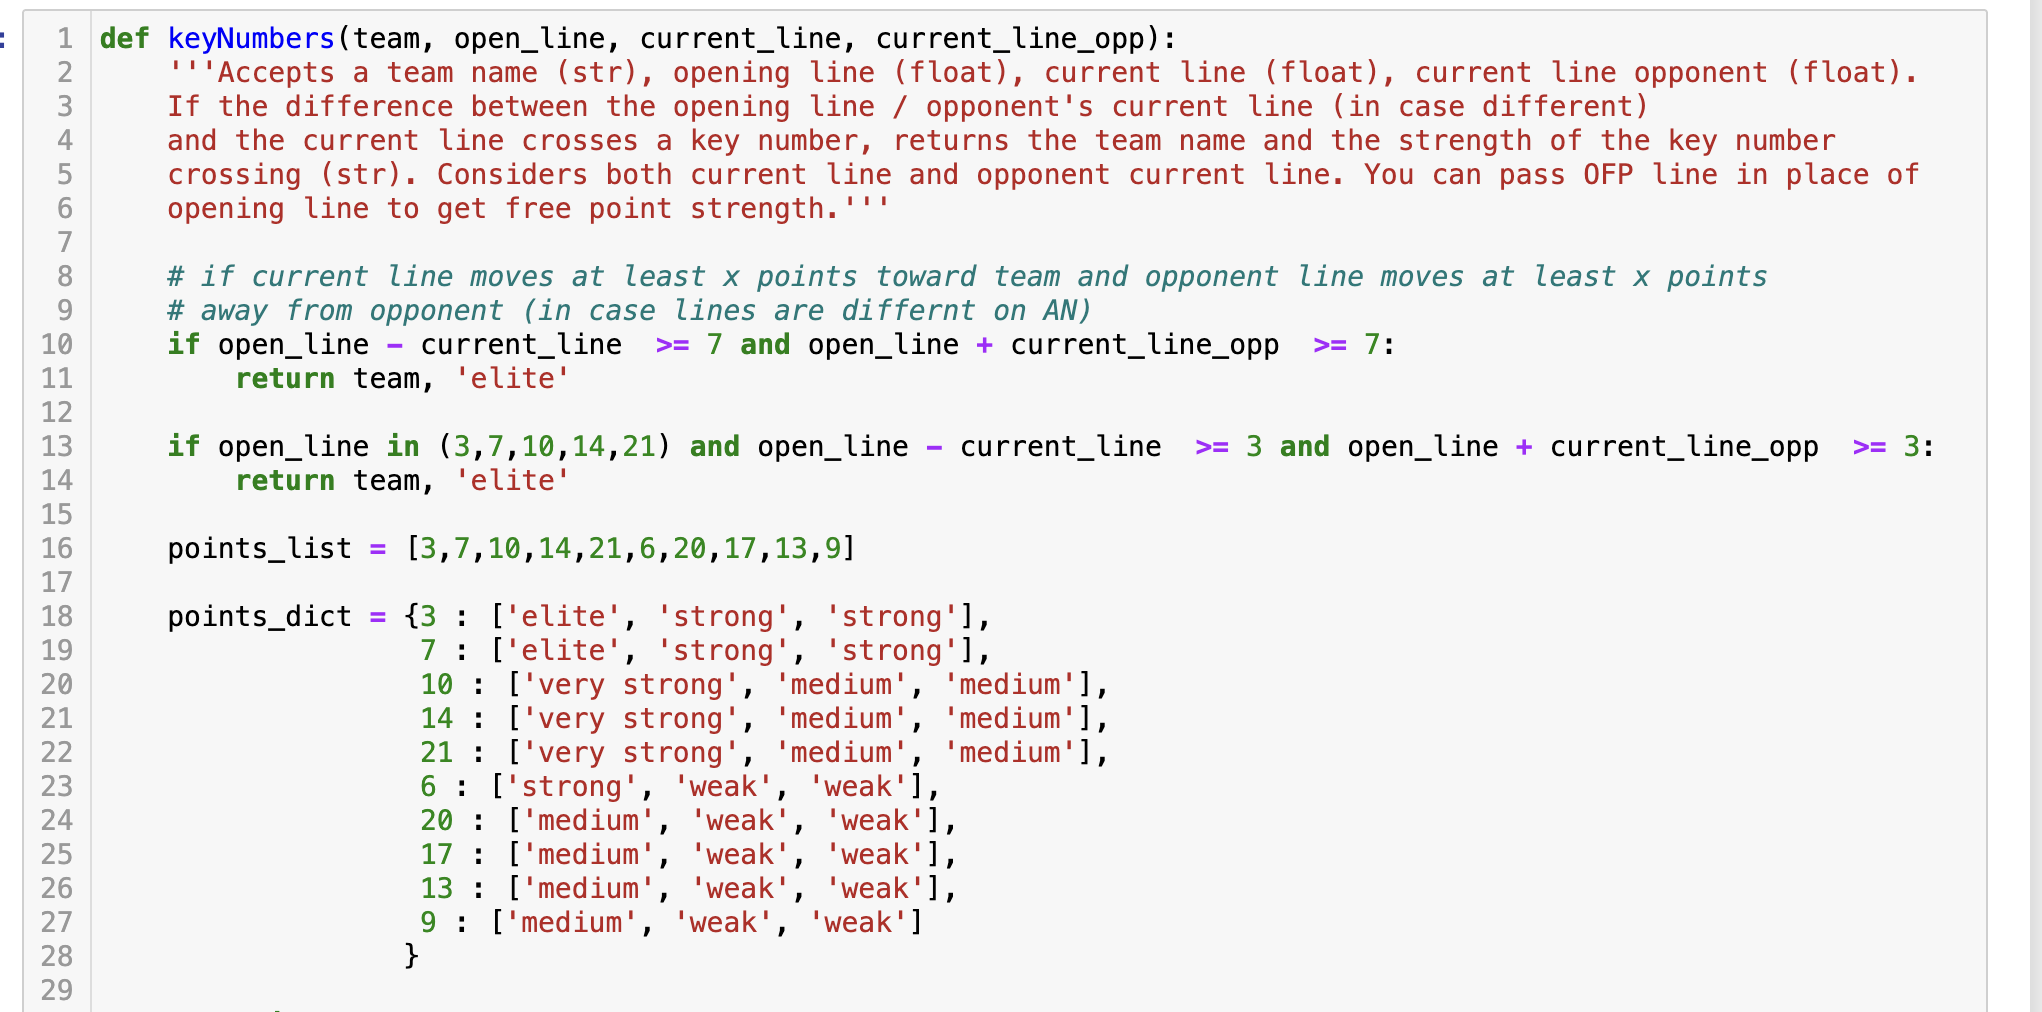

As before let's start by creating a copy of our dataframe.

Then for each game we'll pick whichever team has more complex heuristic points (the complex heuristic points were saved in the database and are in the dataframe so we won't need to calculate it again now). 

Then we'll calculate the performance of the complex heurstic, just as we did with the simple heuristic. 

In [70]:
# create copy of df for the complex heuristic
df_all_complex = df_all.copy()

In [71]:
# determine if home team complex recommendations cover point spread
df_all_complex['complex_rec_home_cover_pred'] = False
df_all_complex.loc[df_all['recommendation_team'] == df_all_complex['home_team'], 'complex_rec_home_cover_pred'] = True

# determine if complex recommendation was accurate
df_all_complex['complex_rec_accurate'] = 0
df_all_complex.loc[df_all['home_covers'] == df_all_complex['complex_rec_home_cover_pred'], 'complex_pred_accurate'] = 1

In [72]:
# get top 4 complex recommendation picks by week
df_all_complex_season_week = get_weekly_top_four(
        sort_picks(
            df_all_complex, score_cols=[
                'max_recommendation_points'], ascending=[
                False]))

In [73]:
# calculate accuracy of complex heuristic 
complex_weekly, complex_correct_rate = correct_picks(
    df_all_complex_season_week, accuracy_col='complex_pred_accurate', description='Complex heuristic')

complex_weekly.head()

cannonical_season_week
2023_05    3.0
2023_06    2.0
2023_07    3.0
2023_08    3.0
2023_09    4.0
Name: complex_pred_accurate, dtype: float64

In [74]:
print(complex_correct_rate)

Complex heuristic got 64.5% of picks correct.


In [75]:
# caclulate correct percent of picks for 2025 season
df_all_complex_season_week_test = df_all_complex_season_week.loc[df_all_complex_season_week['season'] == 2025]

_, complex_correct_rate_test = correct_picks(df_all_complex_season_week_test, 'complex_pred_accurate', 'Complex heuristic 2025 season')

print(complex_correct_rate_test)

Complex heuristic 2025 season got 66.67% of picks correct.


The complex heuristic was a huge perfomance improvement over the simple heuristic overall and for the 2025 season. Our new baseline for 2025 is 66.67% (2/3 correct picks), a blistering pace! 

Let's see if we can beat this using machine learning.

## Use Machine Learning to Pick Games
Our goal is to train a machine learning algorithm on seasons prior to 2025 and then test it on the 2025 season to determine performance. We can create features (also called parameters or predictors) and adjust hyperparameters to try to improve performance.

As we did with the heuristics, we will choose only four games per cannonical week. So we will need to choose an algorithm classification algorithm that also returns a probability score that we can use to sort. Logistic regression seems like a good choice. 

Let's start by creating a copy of our dataframe.

In [76]:
# create copy of df for machine learning
df_lr = df_all.copy()

Any columns that we use for machine learning cannot have null values.

In [77]:
# fill na rows 
df_lr['home_bet_percentage'] = df_lr['home_bet_percentage'].fillna(50)
df_lr['away_bet_percentage'] = df_lr['away_bet_percentage'].fillna(50)

Let's generate a max free points feature for the home team and the away team and convert the odds column from an object to an integer.

In [78]:
# create home and away free points columns
df_lr.loc[df_lr['max_free_points_team'] == df_lr[
    'away_team'], 'away_free_points'] = df_lr.loc[df_lr[
    'max_free_points_team'] == df_lr['away_team'], 'max_free_points']

df_lr.loc[df_lr['max_free_points_team'] == df_lr[
    'home_team'], 'home_free_points'] = df_lr.loc[df_lr[
    'max_free_points_team'] == df_lr['home_team'], 'max_free_points']

df_lr['away_free_points'] = df_lr['away_free_points'].fillna(0)
df_lr['home_free_points'] = df_lr['home_free_points'].fillna(0)

In [79]:
# convert odds columns from objects to integers
df_lr['away_odds'] = df_lr['away_odds'].astype('int')
df_lr['home_odds'] = df_lr['home_odds'].astype('int')

Now let's create a train dataframe using data from seasons before 2025 and a test dataframe using data from the 2025 season. Then we'll select our predictors and train our model on the train dataframe in order to make predictions on the test dataframe.

In [80]:
# split data into training and test data where training data comes before test data
train = df_lr.loc[df_lr['season'] < 2025].copy()
test = df_lr.loc[df_lr['season'] == 2025].copy()

In [81]:
# set predictor columns
predictors = ['away_open_line', 
              'away_current_best_line', 
              'ofp_away_line', 
              'away_odds', 
              'away_bet_percentage', 
              'home_odds', 
              'away_free_points',
              'home_free_points'
             ]

# create X and y train
X_train = train[predictors]
y_train = train['home_covers']

In [82]:
# train lr model 
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression().fit(X_train, y_train)

In [83]:
# create X and y test
X_test = test[predictors]
y_test = test['home_covers']

# use trained lr model to create predictions on test data
pred = clf.predict(X_test)
pred_probs = clf.predict_proba(X_test)

We'll create a column that takes the maximum probability score returned by the logisitic regression algorithm which we'll use to sort the dataframe and make our selections for each cannonical week.

In [84]:
import numpy as np

# create array of max probability for each game
pred_probs_max = np.amax(pred_probs, axis=1)

# add predictions and prediction probabilities columns to test df
test['lr_preds'] = pred
test['lr_pred_probs'] = pred_probs_max

# Determine accuracy of lr model for each game
test['lr_preds_accurate'] = 0
test.loc[test['home_covers'] == test['lr_preds'], 'lr_preds_accurate'] = 1

# get top 4 lr recommendation picks by week
df_lr_season_week_test = get_weekly_top_four(
        sort_picks(
            test, score_cols=[
                'lr_pred_probs']))

In [85]:
# calculate accuracy of lr

lr_weekly, lr_correct_rate_test = correct_picks(
    df_lr_season_week_test, accuracy_col='lr_preds_accurate', description='lr 2025 season')

lr_weekly.head()

cannonical_season_week
2025_01    2
2025_02    4
2025_03    3
2025_04    3
2025_05    1
Name: lr_preds_accurate, dtype: int64

In [86]:
print(lr_correct_rate_test)

lr 2025 season got 61.11% of picks correct.


Not bad! Our first attempt at using machine learning to generate predictions got 61.11% of picks correct for the 2025 season. Not as impressive as our complex algorithm so let's see if we can tune our algorithm to improve performance. 

### Make Running Logistic Regression Repeatable
To avoid repeating code let's make some functions that will allow us to repeatedly run logistic regression with different parameters and hyperparameters.

In [87]:
# Make functions to help us repeatedly run logistic regression
def create_train_test_df(df=df_lr, year=2025, predictors=predictors, target_col='home_covers', feature_scale=None):
    '''
    Create X and y train and X and y test datasets, splitting train and test on year.
    
    Accepts: 
        df (dataframe) : dataframe containing target_col and predictors
        year (int) : train set season < year, test set season >= year
        predictors (list ): predictors used to create X
        target_col (str) : target column model will attempt to predict
        feature_scale (str) : features will be scaled using chosen sklearn preprocessing.StandardScaler() method
        
    Returns test, X_train, y_train, X_test, y_test dataframes.
    
    '''
    
    df = df.copy()
    
    # create train df
    train = df.loc[df['season'] < year].copy()
    test = df.loc[df['season'] >= year].copy()

    # create X and y train
    X_train = train[predictors]
    y_train = train[target_col]
    
    # create X and y test
    X_test = test[predictors]
    y_test = test[target_col]
    
    # scale features
    if feature_scale is not None:
        
        from sklearn import preprocessing
        
        if feature_scale == 'standard':
        
            scaler = preprocessing.StandardScaler().fit(X_train)
            X_train = scaler.transform(X_train)
            X_test = scaler.transform(X_test)
                
        if feature_scale == 'min_max':

            min_max_scaler = preprocessing.MinMaxScaler()
            X_train = min_max_scaler.fit_transform(X_train)
            X_test = min_max_scaler.transform(X_test)
        
    return test, X_train, y_train, X_test, y_test

def run_logistic_regression(X_train, y_train, X_test, y_test, max_iter=1000, C=1.0, solver='lbfgs'):
    
    '''
    Train a logistic regression model.
    
    Accepts:
        X_train (dataframe)
        y_train (dataframe)
        X_test (dataframe)
        y_test (dataframe)
        max_iter (int) : maximum number of iterations the logisitic regression test can run
        
    Returns arrays of predictions and prediction probabilities.
    '''
    
    # fit model
    clf = LogisticRegression(max_iter=max_iter, C=C, solver=solver).fit(X_train, y_train)

    # use trained lr model create predictions on test data
    pred = clf.predict(X_test)
    pred_probs = clf.predict_proba(X_test)

    return pred, pred_probs

def append_lr_results(df, pred, pred_probs, target_col):
    '''
    Append predictions and prediction probabilities of a logisitic regression model onto a dataframe and 
    determine accuracy of prediction.
    
    Accepts:
        df (dataframe) : dataframe that results will be appended onto, should contain target_col
        pred (array) : An array of predictions
        pred_probs (array) : An array of prediction probabilities produced by sklearn LogisticRegression
        target_col (str) : target column model attempted to predict
        
    Returns dataframe appended with lr_preds, lr_pred_probs, lr_preds_accurate.
    '''
    
    df = df.copy()
    
    # create array of max probability for each game
    import numpy as np
    pred_probs_max = np.amax(pred_probs, axis=1)
    
    # add predictions and prediction probabilities columns to test df
    df['lr_preds'] = pred
    df['lr_pred_probs'] = pred_probs_max
    
    # Determine accuracy of lr model for each game
    df['lr_preds_accurate'] = 0
    df.loc[df[target_col] == df['lr_preds'], 'lr_preds_accurate'] = 1
    
    return df

### Use Feature Scaling
If features use different scales (like bet percentage vs free points) it can affect the performance of the machine learning algorithm. Let's scale our features so they are all using the same scale which can improve accuracy of the algorithm. 

There are two approaches that we will test here: 
1. Standardization - Scale values to set the mean to 0 and each standard deviation in either direction to +1 or -1
2. Normalization (min max) - Shift values so that they are between 0 and 1 

We'll test both starting with standardization.

In [88]:
# scale features using standardization
from sklearn import preprocessing

scaler = preprocessing.StandardScaler().fit(X_train)

X_scaled = scaler.transform(X_train)

Create test and train datasets

In [89]:
# create test and train datasets
df_test, X_train, y_train, X_test, y_test = create_train_test_df(feature_scale='standard')

Train logistic regression using standardized features on train dataset, make predictions on holdout/test dataset (2025 season) and calculate performance.

In [90]:
# run logistic regression
pred_, pred_probs_ = run_logistic_regression(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

In [91]:
# create results dataframe
df_scaled = append_lr_results(df=df_test, pred=pred_, pred_probs=pred_probs_, target_col='home_covers')

In [92]:
scaled_lr_weekly_top_four_result_df, scaled_lr_weekly_correct_picks, scaled_lr_correct_rate = make_predictions(
    df=df_scaled, 
    score_cols=['lr_pred_probs'], 
    ascending=[False], 
    accuracy_col='lr_preds_accurate', 
    description='Standardized features'
)

scaled_lr_correct_rate

'Standardized features got 59.72% of picks correct.'

Standardizing features made performance a bit worse. 

Let's create another function that will call the all the logisitic regression helper functions we created above to streamline running logisitic regression.

Then let's test normalizing features.

In [93]:
def full_logistic_regression(df=df_lr, year=2025, predictors=predictors, target_col='home_covers', max_iter=1000, feature_scale=False, C=1.0, solver='lbfgs'):
    '''
    Call functions create_train_test_df, run_logistic_regression, append_lr_results.
    
    Accepts: 
        df (dataframe) : dataframe containing target_col and predictors
        year (int) : train set season < year, test set season >= year
        predictors (list ): predictors used to create X
        target_col (str) : target column model will attempt to predict
        max_iter (int) : maximum number of iterations the logisitic regression test can run
        feature_scale (bool) : if True features will be scaled using sklearn preprocessing.StandardScaler()
        C (float) : inverse of regularization strength
        solver (str) : algorithm to use in the optimization problem
        
    Returns dataframe appended with lr_preds, lr_pred_probs, lr_preds_accurate.
        
    '''
    
    test_df, X_train, y_train, X_test, y_test = create_train_test_df(df=df, year=year, predictors=predictors, target_col=target_col, feature_scale=feature_scale)
    
    pred, pred_probs = run_logistic_regression(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, max_iter=max_iter, C=C, solver=solver)
    
    df = append_lr_results(df=test_df, pred=pred, pred_probs=pred_probs, target_col=target_col)
    
    return pred, pred_probs, df

In [94]:
# normalize features using mix max
pred, pred_probs, df_scaled_min_max = full_logistic_regression(feature_scale='min_max')

In [95]:
scaled_lr_weekly_top_four_result_df, scaled_lr_weekly_correct_picks, scaled_lr_correct_rate = make_predictions(
    df=df_scaled_min_max, 
    score_cols=['lr_pred_probs'], 
    ascending=[False], 
    accuracy_col='lr_preds_accurate', 
    description='Normalized features'
)

scaled_lr_correct_rate

'Normalized features got 62.5% of picks correct.'

Normalizing features improved performance over baseline slightly but we're still lagging our complex algorithm. Now let's try generating some new features.

### Generate New Features
#### Key Numbers
I mentioned that our complex heuristic leans heavily on free points crossing a key number or combinations of key numbers. Let's create a function that will help us create boolean features based on whether or not a free points crossed a key number for a given team in a given game.

In [96]:
# create functions to help us with feature generation 
def crosses_key_number(df, key_number, description):
    '''
    Create features based on free points crossing a key number.
    
    Args:
        df (pandas dataframe): dataframe containing key number cols
        key_number (int): key number that is crossed
        description (str): description of key number
        
    Returns a dataframe with game_id and the new feature columns.
    '''

    df_tmp = df.copy()
    
    away_underdog_col_name = '_'.join(('away_free_points_crosses',description,'underdog'))
    away_favorite_col_name = '_'.join(('away_free_points_crosses',description,'favorite'))
    home_underdog_col_name = '_'.join(('home_free_points_crosses',description,'underdog'))
    home_favorite_col_name = '_'.join(('home_free_points_crosses',description,'favorite'))
    
    feature_cols = [away_underdog_col_name, away_favorite_col_name, home_underdog_col_name, home_favorite_col_name]
    feature_cols_game_id = feature_cols.copy()
    feature_cols_game_id.insert(0, 'game_id')
    
    df_tmp[away_underdog_col_name] = False
    df_tmp[away_favorite_col_name] = False
    df_tmp[home_underdog_col_name] = False
    df_tmp[home_favorite_col_name] = False
    
    df_tmp.loc[(df_tmp['ofp_away_line'] > key_number) & (df[
        'away_current_best_line'] < key_number)  & (
        df_tmp['home_current_best_line'] > (-1*key_number)), away_underdog_col_name] = True

    df_tmp.loc[(df_tmp['ofp_away_line'] > (-1*key_number)) & (df[
        'away_current_best_line'] < (-1*key_number))  & (
        df_tmp['home_current_best_line'] > key_number), away_favorite_col_name] = True

    df_tmp.loc[(df['ofp_home_line'] > key_number) & (df[
        'home_current_best_line'] < key_number)  & (
        df_tmp['away_current_best_line'] > (-1*key_number)), home_underdog_col_name] = True

    df_tmp.loc[(df_tmp['ofp_home_line'] > (-1*key_number)) & (df[
        'home_current_best_line'] < (-1*key_number))  & (
        df_tmp['away_current_best_line'] > key_number), home_favorite_col_name] = True
    
    return df_tmp[feature_cols_game_id], feature_cols

key_numbers = {
    3 : 'fg',
    6 : 'two_fg',
    7 : 'td',
    10 : 'td_fg',
    14 : 'two_td',
    21 : 'three_td'
}

Let's create a new dataframe that includes our new key number features.

In [97]:
# create a new dataframe for our features
df_features = df_lr.copy()
predictors_key_numbers = predictors.copy()

# create feature columns and append feature name to predictors list

for k, v in key_numbers.items():
    df_features_tmp, feature_cols_tmp = crosses_key_number(df_lr, k, v)
    df_features = pd.merge(left=df_features, right=df_features_tmp, on='game_id')
    for feature in feature_cols_tmp:
        predictors_key_numbers.append(feature)

Let's run logisitic regression using our new features using feature normalization.

In [98]:
# run logistic regression with key number features
_pred, _pred_probs, df_features_preds = full_logistic_regression(
    df=df_features, 
    predictors=predictors_key_numbers, 
    feature_scale='min_max'
)

In [99]:
# calculate pick accuracy of logistic regression with key number features
df_features_season_week, features_weekly, features_correct_rate = make_predictions(
    df=df_features_preds,
    score_cols=['lr_pred_probs'], 
    ascending=[False], 
    accuracy_col='lr_preds_accurate', 
    description='Key Numbers Features Logisitic Regression'
)

In [100]:
features_correct_rate

'Key Numbers Features Logisitic Regression got 62.5% of picks correct.'

Adding the new features did not result in a performance improvement. Let's run logistic regression again using the new features but without feature normalization.

In [101]:
# run logistic regression with key number features
_pred, _pred_probs, df_features_preds = full_logistic_regression(
    df=df_features, 
    predictors=predictors_key_numbers, 
#     feature_scale='min_max'
)

In [102]:
# calculate pick accuracy of logistic regression with key number features
df_features_season_week, features_weekly, features_correct_rate = make_predictions(
    df=df_features_preds,
    score_cols=['lr_pred_probs'], 
    ascending=[False], 
    accuracy_col='lr_preds_accurate', 
    description='Key Numbers Features Logisitic Regression'
)

In [103]:
features_correct_rate

'Key Numbers Features Logisitic Regression got 63.89% of picks correct.'

Removing feature normalization gave us a small boost in performance when using our new features. Let's create some more features that are also included in the complex heuristic.

#### Add Reverse Line Movement Feature
Earlier I mentioned reverse line movement was a factor in the complex heuristic. When a team has a smaller portion of the public bets but the line moves in such a way to make it less advantageous to bet on that team, it is called reverse line movement. It can be an indicator that sharp bettors are betting on that team. The lower the percentage of bets on a team, the more meaningful it is that the line moved against that team. 

Let's create a reverse line movement feature for each decile of public bet percentage below 50%. Ultimately these features will exist as booleans for each decile with terms of art based on the decile, e.g. away_reverse_line_elite if the away team has less than 10% of the public bets and the line moves against the away team.

In [104]:
# create reverse line movement features
predictors_reverse_line = predictors.copy()
predictors_key_numbers_reverse_line = predictors_key_numbers.copy()

reverse_line_dict = {'elite' : 10,
                    'very_strong' : 20,
                    'strong' : 30,
                    'medium' : 40,
                    'low' : 50}

reverse_line_dict_sorted = dict(sorted(reverse_line_dict.items(), key=lambda item: item[1], reverse=True))

for description, bet_per in reverse_line_dict_sorted.items():
    df_features.loc[(df_features['away_current_best_line'] < df_features['away_open_line']) & (
        df_features['away_bet_percentage'] < bet_per), 'away_reverse_line_movement'] = description 
    
    predictors_reverse_line.append('_'.join(('away_reverse_line', description)))
    predictors_key_numbers_reverse_line.append('_'.join(('away_reverse_line', description)))
    
    df_features.loc[(df_features['home_current_best_line'] < df_features['home_open_line']) & (
        df_features['home_bet_percentage'] < bet_per), 'home_reverse_line_movement'] = description 
                                   
    predictors_reverse_line.append('_'.join(('home_reverse_line', description)))
    predictors_key_numbers_reverse_line.append('_'.join(('home_reverse_line', description)))

# create dummy cols
away_reverse_dummies = pd.get_dummies(df_features['away_reverse_line_movement'], prefix='away_reverse_line')
home_reverse_dummies = pd.get_dummies(df_features['home_reverse_line_movement'], prefix='home_reverse_line')

# Let's merge our features back 
df_features = pd.merge(df_features, away_reverse_dummies, left_index=True, right_index=True)
df_features = pd.merge(df_features, home_reverse_dummies, left_index=True, right_index=True)

Let's run logistic regression with our reverse line movement features (but no key number features) and calculate performance.

In [105]:
# run logistic regression with reverse live movement features
_pred, _pred_probs, df_reverse_line_preds = full_logistic_regression(
    df=df_features, 
    predictors=predictors_reverse_line, 
#     feature_scale='min_max'
)

In [106]:
# calculate pick accuracy of logistic regression with key number features
df_reverse_line_season_week, reverse_line_weekly, reverse_line_correct_rate = make_predictions(
    df=df_reverse_line_preds,
    score_cols=['lr_pred_probs'], 
    ascending=[False], 
    accuracy_col='lr_preds_accurate', 
    description='Reverse Line Movement Features Logisitic Regression'
)

In [107]:
reverse_line_correct_rate

'Reverse Line Movement Features Logisitic Regression got 59.72% of picks correct.'

Performance got a bit worse when using our reverse line movement features but not key number features. Let's try adding back the key number features and running logistic regression again (both reverse line movement and key number features). (Note that I got a max iteration warning so I increased `max_iter` to 10000 below.)

In [108]:
# run logistic regression with key number and reverse live movement features
_pred, _pred_probs, df_key_numbers_reverse_line_preds = full_logistic_regression(
    df=df_features, 
    max_iter = 10000,
    predictors=predictors_key_numbers_reverse_line, 
#     feature_scale='min_max'
)

In [109]:
# calculate pick accuracy of logistic regression with key number features
df_key_number_reverse_line_season_week, key_number_reverse_line_weekly, key_number_reverse_line_correct_rate = make_predictions(
    df=df_key_numbers_reverse_line_preds,
    score_cols=['lr_pred_probs'], 
    ascending=[False], 
    accuracy_col='lr_preds_accurate', 
    description='Key Numbers + Reverse Line Movement Features Logisitic Regression'
)

In [110]:
key_number_reverse_line_correct_rate

'Key Numbers + Reverse Line Movement Features Logisitic Regression got 62.5% of picks correct.'

Performance is slightly worse when combining key numbers and reverse line movement features vs using just key number features. Let's scrap our reverse line movement features.

Let's move on to hyperparameter tuning.

## Hyperparameter Tuning
Hyperparameter tuning allows adjust the settings of the model to try to improve performance (among other objectives like reducing overfitting and underfitting).

The two logisitic regression hyperparamters I would like to focus on are:
- C: inverse regularization strength, help pervent overfitting by adjusting the loss function 
- Solvers: choose the algorithm:
  - `liblinear` is well suited for smalled datasets like ours 
  - `lbfgs` (which is the default) is well suited to a many different classes of problems.

Let's run logistic regression using our key numbers features and test combinations of these hyperparameters below.

In [111]:
Cs = [1, 10, 100, 1000]
solvers = ['liblinear', 'lbfgs']

In [112]:
for solver in solvers:
    for C in Cs:
        _, __, df_features_preds = full_logistic_regression(
            df=df_features,
            feature_scale=False, 
            predictors=predictors_key_numbers, 
            C=C,
            max_iter=10000,
            solver=solver)
        _, __, lr_correct_rate = make_predictions(
            df=df_features_preds,
            score_cols=['lr_pred_probs'], 
            ascending=[False], 
            accuracy_col='lr_preds_accurate', 
            description=' '.join(('Logisitic Regression',str(C),solver))
        )
        print(lr_correct_rate)

Logisitic Regression 1 liblinear got 63.89% of picks correct.
Logisitic Regression 10 liblinear got 66.67% of picks correct.
Logisitic Regression 100 liblinear got 66.67% of picks correct.
Logisitic Regression 1000 liblinear got 66.67% of picks correct.
Logisitic Regression 1 lbfgs got 63.89% of picks correct.
Logisitic Regression 10 lbfgs got 66.67% of picks correct.
Logisitic Regression 100 lbfgs got 66.67% of picks correct.
Logisitic Regression 1000 lbfgs got 65.28% of picks correct.


A few different combinations of hyperparameters were able to deliver performance 66.67% (2/3 correct picks), matching our complex heuristic. I'm actually pretty pleased with this because I spent a lot of time fine tuning my complex heuristic. I expect that our machine learning performance will improve as we generate more data to help train out model.

I'm going to pause here for now because I want to deliver this in time for the start of the 2026 NFL season. 

Using feature generation and hyperparameter optimization (and testing feature scaling) we were able to use a dataset of less than 2,000 records train a model that got 2/3 picks correct. 

I will certainly continue working on this project. The more data we collect, the better I expect the algorithm to perform. 

Thank you for reading! 